========== DATASET LOADED ==========
Rows: 700
Columns: 11

First 5 rows:
   User ID    Device Model Operating System  App Usage Time (min/day)  \
0        1  Google Pixel 5          Android                       393   
1        2       OnePlus 9          Android                       268   
2        3    Xiaomi Mi 11          Android                       154   
3        4  Google Pixel 5          Android                       239   
4        5       iPhone 12              iOS                       187   

   Screen On Time (hours/day)  Battery Drain (mAh/day)  \
0                         6.4                     1872   
1                         4.7                     1331   
2                         4.0                      761   
3                         4.8                     1676   
4                         4.3                     1367   

   Number of Apps Installed  Data Usage (MB/day)  Age  Gender  \
0                        67                 1122   40    Male   
1       

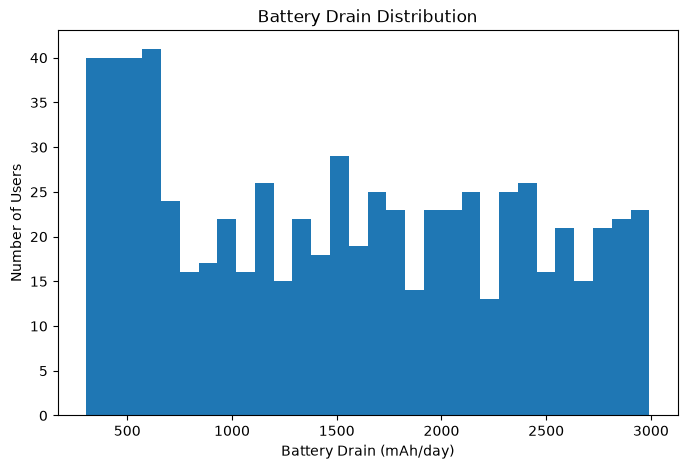


========== CATEGORICAL FEATURES ==========

Device Model:
Device Model
Xiaomi Mi 11          146
iPhone 12             146
Google Pixel 5        142
OnePlus 9             133
Samsung Galaxy S21    133
Name: count, dtype: int64

Operating System:
Operating System
Android    554
iOS        146
Name: count, dtype: int64

Gender:
Gender
Male      364
Female    336
Name: count, dtype: int64


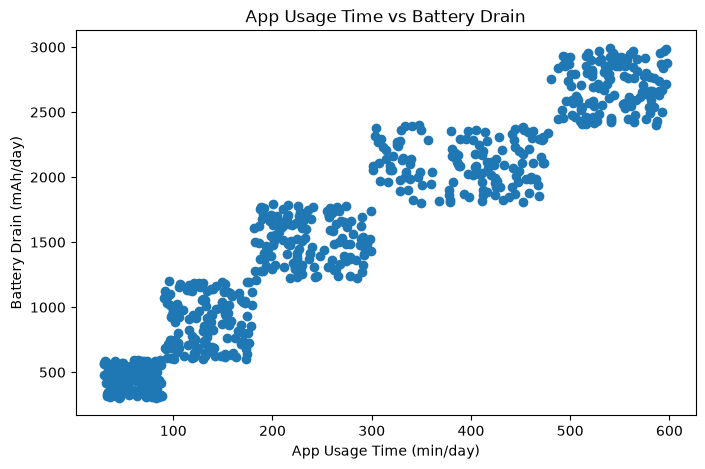

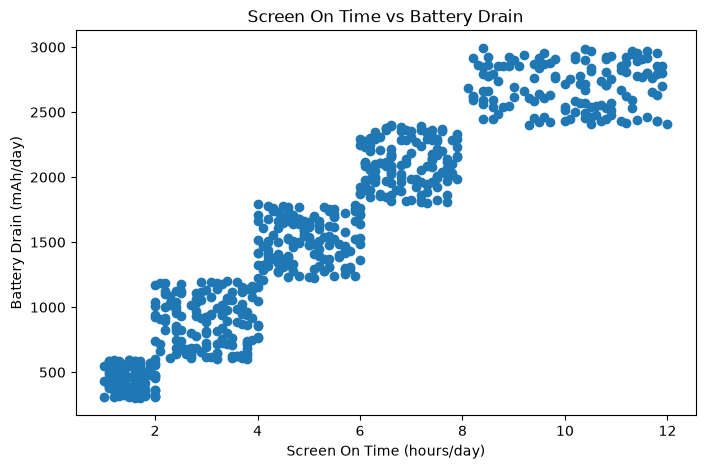

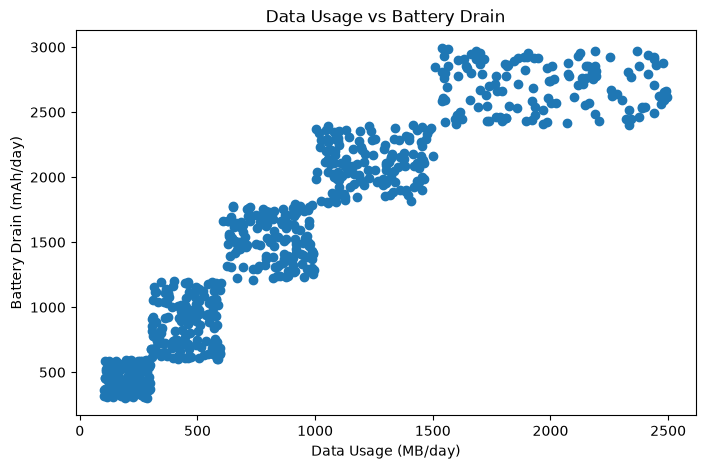


========== CORRELATION MATRIX ==========
                            App Usage Time (min/day)  \
App Usage Time (min/day)                    1.000000   
Screen On Time (hours/day)                  0.950333   
Battery Drain (mAh/day)                     0.956385   
Number of Apps Installed                    0.955253   
Data Usage (MB/day)                         0.942308   
Age                                         0.004382   

                            Screen On Time (hours/day)  \
App Usage Time (min/day)                      0.950333   
Screen On Time (hours/day)                    1.000000   
Battery Drain (mAh/day)                       0.948983   
Number of Apps Installed                      0.946975   
Data Usage (MB/day)                           0.941322   
Age                                           0.017232   

                            Battery Drain (mAh/day)  Number of Apps Installed  \
App Usage Time (min/day)                   0.956385                  0.955253

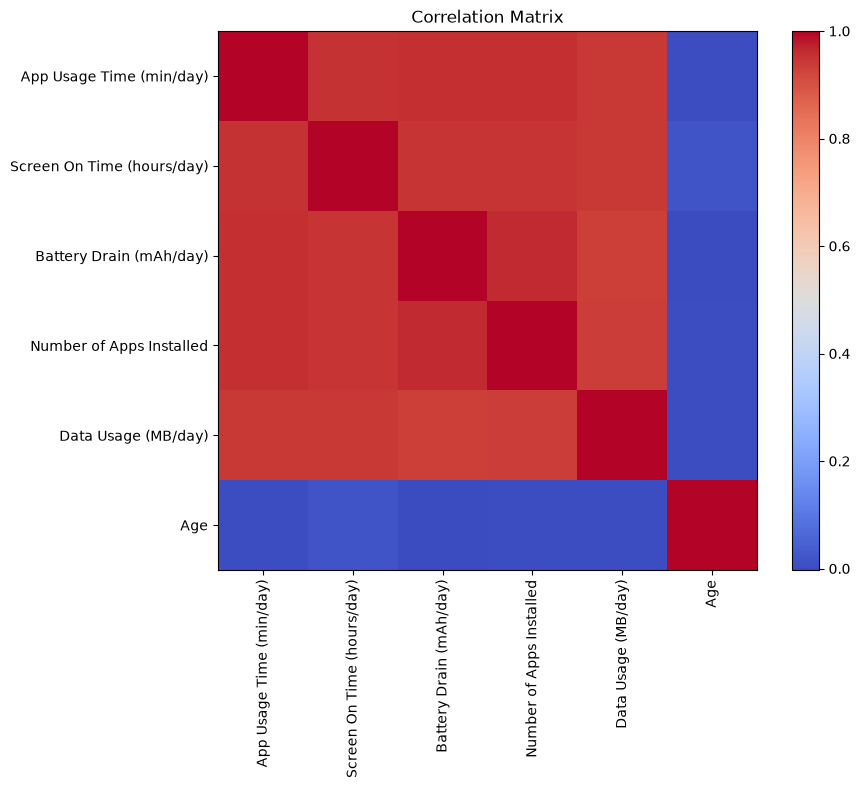

In [ ]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



df = pd.read_csv("user_behavior_dataset.csv")

print("========== DATASET LOADED ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFirst 5 rows:")
print(df.head())




print("\n========== DATA INFORMATION ==========")
df.info()

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())




print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE ROWS ==========")
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])




print("\n========== UNIQUE VALUES ==========")

for column in df.columns:
    print("\n", column)
    print(df[column].unique()[:10])




target = "Battery Drain (mAh/day)"

print("\n========== TARGET ANALYSIS ==========")
print("Target variable:", target)

print("\nTarget statistics:")
print(df[target].describe())

# Target distribution
plt.figure(figsize=(8, 5))

plt.hist(df[target], bins=30)

plt.xlabel("Battery Drain (mAh/day)")
plt.ylabel("Number of Users")
plt.title("Battery Drain Distribution")

plt.show()




print("\n========== CATEGORICAL FEATURES ==========")

print("\nDevice Model:")
print(df["Device Model"].value_counts())

print("\nOperating System:")
print(df["Operating System"].value_counts())

print("\nGender:")
print(df["Gender"].value_counts())


# ---- App Usage vs Battery Drain ----

plt.figure(figsize=(8, 5))

plt.scatter(
    df["App Usage Time (min/day)"],
    df["Battery Drain (mAh/day)"]
)

plt.xlabel("App Usage Time (min/day)")
plt.ylabel("Battery Drain (mAh/day)")
plt.title("App Usage Time vs Battery Drain")

plt.show()


# ---- Screen Time vs Battery Drain ----

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Screen On Time (hours/day)"],
    df["Battery Drain (mAh/day)"]
)

plt.xlabel("Screen On Time (hours/day)")
plt.ylabel("Battery Drain (mAh/day)")
plt.title("Screen On Time vs Battery Drain")

plt.show()


# ---- Data Usage vs Battery Drain ----

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Data Usage (MB/day)"],
    df["Battery Drain (mAh/day)"]
)

plt.xlabel("Data Usage (MB/day)")
plt.ylabel("Battery Drain (mAh/day)")
plt.title("Data Usage vs Battery Drain")

plt.show()


# ---- Correlation Analysis ----

numeric_columns = [
    "App Usage Time (min/day)",
    "Screen On Time (hours/day)",
    "Battery Drain (mAh/day)",
    "Number of Apps Installed",
    "Data Usage (MB/day)",
    "Age"
]

correlation = df[numeric_columns].corr()

print("\n========== CORRELATION MATRIX ==========")
print(correlation)


# Correlation visualization
plt.figure(figsize=(9, 7))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.show()

========== STEP 9: X AND y ==========

Features (X):
['Device Model', 'Operating System', 'App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Number of Apps Installed', 'Data Usage (MB/day)', 'Age', 'Gender']

Target (y):
Battery Drain (mAh/day)

X shape: (700, 8)
y shape: (700,)

========== STEP 10: FEATURE TYPES ==========

Categorical features:
['Device Model', 'Operating System', 'Gender']

Numerical features:
['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Number of Apps Installed', 'Data Usage (MB/day)', 'Age']

========== STEP 11: TRAIN-TEST SPLIT ==========
Training X: (560, 8)
Testing X : (140, 8)
Training y: (560,)
Testing y : (140,)

========== STEP 12: ENCODING ==========
Categorical features will be converted using One-Hot Encoding.
Numerical features will remain unchanged.

========== STEP 13: MODEL TRAINED ==========
Linear Regression model trained successfully.

========== STEP 14: PREDICTIONS ==========

First 10 Actual Values:
[2375  369  437  893 1

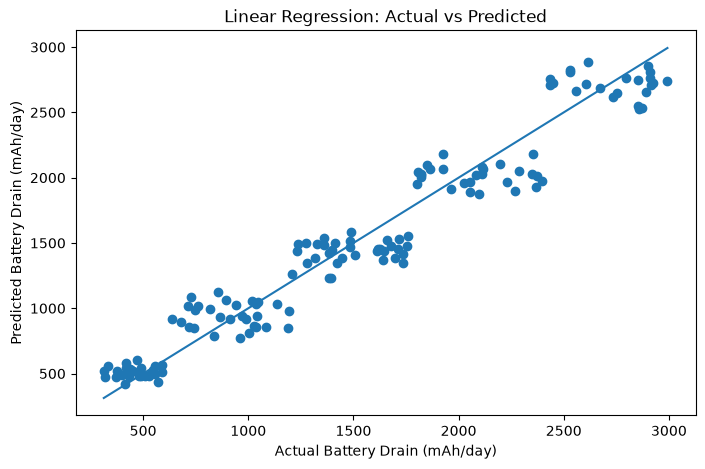

In [5]:
# ============================================================
# SMARTPHONE BATTERY DRAIN PREDICTION
# STEPS 9–15 : LINEAR REGRESSION ONLY
# ============================================================

# ------------------------------------------------------------
# 9. SEPARATE FEATURES (X) AND TARGET (y)
# ------------------------------------------------------------

X = df.drop("Battery Drain (mAh/day)", axis=1)

y = df["Battery Drain (mAh/day)"]

print("========== STEP 9: X AND y ==========")

print("\nFeatures (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print("Battery Drain (mAh/day)")

print("\nX shape:", X.shape)
print("y shape:", y.shape)


# ------------------------------------------------------------
# 10. IDENTIFY CATEGORICAL AND NUMERICAL FEATURES
# ------------------------------------------------------------

categorical_features = [
    "Device Model",
    "Operating System",
    "Gender"
]

numerical_features = [
    "App Usage Time (min/day)",
    "Screen On Time (hours/day)",
    "Number of Apps Installed",
    "Data Usage (MB/day)",
    "Age"
]

print("\n========== STEP 10: FEATURE TYPES ==========")

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)


# ------------------------------------------------------------
# 11. TRAIN-TEST SPLIT
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n========== STEP 11: TRAIN-TEST SPLIT ==========")

print("Training X:", X_train.shape)
print("Testing X :", X_test.shape)

print("Training y:", y_train.shape)
print("Testing y :", y_test.shape)


# ------------------------------------------------------------
# 12. ONE-HOT ENCODING
# ------------------------------------------------------------

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("\n========== STEP 12: ENCODING ==========")
print("Categorical features will be converted using One-Hot Encoding.")
print("Numerical features will remain unchanged.")


# ------------------------------------------------------------
# 13. CREATE AND TRAIN LINEAR REGRESSION MODEL
# ------------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Train the model
linear_model.fit(X_train, y_train)

print("\n========== STEP 13: MODEL TRAINED ==========")
print("Linear Regression model trained successfully.")


# ------------------------------------------------------------
# 14. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = linear_model.predict(X_test)

print("\n========== STEP 14: PREDICTIONS ==========")

print("\nFirst 10 Actual Values:")
print(y_test.values[:10])

print("\nFirst 10 Predicted Values:")
print(y_pred[:10])


# Compare actual vs predicted
comparison = pd.DataFrame({
    "Actual Battery Drain": y_test.values,
    "Predicted Battery Drain": y_pred
})

print("\n========== ACTUAL VS PREDICTED ==========")
print(comparison.head(10))


# ------------------------------------------------------------
# 15. MODEL EVALUATION
# ------------------------------------------------------------

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("\n========== STEP 15: MODEL EVALUATION ==========")

print("Mean Absolute Error (MAE) :", mae)
print("Mean Squared Error (MSE)  :", mse)
print("Root Mean Squared Error   :", rmse)
print("R2 Score                  :", r2)


# ------------------------------------------------------------
# ACTUAL VS PREDICTED GRAPH
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred
)

# Ideal prediction line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum]
)

plt.xlabel("Actual Battery Drain (mAh/day)")
plt.ylabel("Predicted Battery Drain (mAh/day)")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [6]:
# ============================================================
# STEP 16: PREDICT BATTERY DRAIN FOR A NEW USER
# ============================================================

# New user's information
new_user = pd.DataFrame({
    "Device Model": ["Google Pixel 5"],
    "Operating System": ["Android"],
    "App Usage Time (min/day)": [300],
    "Screen On Time (hours/day)": [5.5],
    "Number of Apps Installed": [50],
    "Data Usage (MB/day)": [900],
    "Age": [25],
    "Gender": ["Male"]
})

# Make prediction
predicted_battery_drain = linear_model.predict(new_user)

print("========== NEW USER PREDICTION ==========")

print("Device Model:", new_user["Device Model"].iloc[0])
print("App Usage:", new_user["App Usage Time (min/day)"].iloc[0], "min/day")
print("Screen Time:", new_user["Screen On Time (hours/day)"].iloc[0], "hours/day")
print("Data Usage:", new_user["Data Usage (MB/day)"].iloc[0], "MB/day")

print("\nPredicted Battery Drain:",
      round(predicted_battery_drain[0], 2),
      "mAh/day")

========== NEW USER PREDICTION ==========
Device Model: Google Pixel 5
App Usage: 300 min/day
Screen Time: 5.5 hours/day
Data Usage: 900 MB/day

Predicted Battery Drain: 1543.61 mAh/day


========== STEP 17: FEATURE IMPORTANCE ==========
                                         Feature  Coefficient  Absolute Impact
10         remainder__Screen On Time (hours/day)    54.600977        54.600977
3         categorical__Device Model_Xiaomi Mi 11    23.120833        23.120833
0       categorical__Device Model_Google Pixel 5   -22.136233        22.136233
11           remainder__Number of Apps Installed    12.926937        12.926937
2   categorical__Device Model_Samsung Galaxy S21   -12.610209        12.610209
1            categorical__Device Model_OnePlus 9     7.681609         7.681609
7                     categorical__Gender_Female     6.260897         6.260897
8                       categorical__Gender_Male    -6.260897         6.260897
4            categorical__Device Model_iPhone 12     3.944001         3.944001
6              categorical__Operating System_iOS     3.944001         3.944001
5          categorical__Operating System_Android    -3.944001         3.944001
9 

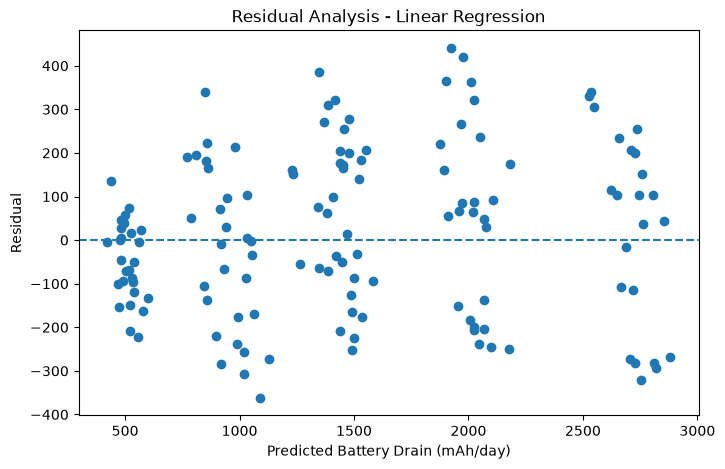


========== STEP 20: MULTIPLE USER PREDICTION ==========
     Device Model  App Usage Time (min/day)  Screen On Time (hours/day)  \
0  Google Pixel 5                       200                           4   
1       OnePlus 9                       350                           6   
2    Xiaomi Mi 11                       450                           8   

   Data Usage (MB/day)  Predicted Battery Drain (mAh/day)  
0                  500                        1180.558542  
1                 1000                        1802.123110  
2                 1500                        2375.826828  


In [ ]:


# Get feature names after One-Hot Encoding
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()

# Get Linear Regression coefficients
coefficients = linear_model.named_steps["model"].coef_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Absolute coefficient tells how strongly the feature affects prediction
feature_importance["Absolute Impact"] = abs(
    feature_importance["Coefficient"]
)

feature_importance = feature_importance.sort_values(
    by="Absolute Impact",
    ascending=False
)

print("========== STEP 17: FEATURE IMPORTANCE ==========")
print(feature_importance)


# ------------------------------------------------------------
# STEP 18: ACTUAL VS PREDICTED VALUES
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Difference"] = (
    comparison["Actual"] - comparison["Predicted"]
)

print("\n========== STEP 18: ACTUAL VS PREDICTED ==========")
print(comparison.head(15))


# ------------------------------------------------------------
# STEP 19: RESIDUAL ANALYSIS
# ------------------------------------------------------------

residuals = y_test.values - y_pred

print("\n========== STEP 19: RESIDUAL ANALYSIS ==========")

print("Mean Residual:", np.mean(residuals))
print("Minimum Residual:", np.min(residuals))
print("Maximum Residual:", np.max(residuals))

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Battery Drain (mAh/day)")
plt.ylabel("Residual")
plt.title("Residual Analysis - Linear Regression")

plt.show()


# ------------------------------------------------------------
# STEP 20: PREDICT FOR MULTIPLE NEW USERS
# ------------------------------------------------------------

new_users = pd.DataFrame({

    "Device Model": [
        "Google Pixel 5",
        "OnePlus 9",
        "Xiaomi Mi 11"
    ],

    "Operating System": [
        "Android",
        "Android",
        "Android"
    ],

    "App Usage Time (min/day)": [
        200,
        350,
        450
    ],

    "Screen On Time (hours/day)": [
        4,
        6,
        8
    ],

    "Number of Apps Installed": [
        40,
        60,
        80
    ],

    "Data Usage (MB/day)": [
        500,
        1000,
        1500
    ],

    "Age": [
        22,
        30,
        25
    ],

    "Gender": [
        "Female",
        "Male",
        "Female"
    ]
})

multiple_predictions = linear_model.predict(new_users)

new_users["Predicted Battery Drain (mAh/day)"] = multiple_predictions

print("\n========== STEP 20: MULTIPLE USER PREDICTION ==========")

print(
    new_users[
        [
            "Device Model",
            "App Usage Time (min/day)",
            "Screen On Time (hours/day)",
            "Data Usage (MB/day)",
            "Predicted Battery Drain (mAh/day)"
        ]
    ]
)






In [9]:
# ============================================================
# BATTERY DRAIN RISK CLASSIFICATION
# ============================================================

def classify_drain(drain):
    if drain < 1000:
        return "Low"
    elif drain < 1500:
        return "Medium"
    else:
        return "High"


new_users["Battery Drain Level"] = new_users[
    "Predicted Battery Drain (mAh/day)"
].apply(classify_drain)

print("========== BATTERY DRAIN LEVEL ==========")

print(
    new_users[
        [
            "Device Model",
            "Predicted Battery Drain (mAh/day)",
            "Battery Drain Level"
        ]
    ]
)

========== BATTERY DRAIN LEVEL ==========
     Device Model  Predicted Battery Drain (mAh/day) Battery Drain Level
0  Google Pixel 5                        1180.558542              Medium
1       OnePlus 9                        1802.123110                High
2    Xiaomi Mi 11                        2375.826828                High


In [12]:
# ============================================================
# BATTERY USAGE RECOMMENDATIONS
# ============================================================

new_users["Recommendation"] = "Normal usage"

new_users.loc[
    new_users["Screen On Time (hours/day)"] >= 6,
    "Recommendation"
] = "Reduce screen time"

new_users.loc[
    new_users["App Usage Time (min/day)"] >= 300,
    "Recommendation"
] = "Reduce app usage"

new_users.loc[
    new_users["Data Usage (MB/day)"] >= 1000,
    "Recommendation"
] = "Reduce data usage"

new_users.loc[
    new_users["Number of Apps Installed"] >= 60,
    "Recommendation"
] = "Remove unnecessary apps"

print(new_users[
    [
        "Device Model",
        "Predicted Battery Drain (mAh/day)",
        "Battery Drain Level",
        "Recommendation"
    ]
])

     Device Model  Predicted Battery Drain (mAh/day) Battery Drain Level  \
0  Google Pixel 5                        1180.558542              Medium   
1       OnePlus 9                        1802.123110                High   
2    Xiaomi Mi 11                        2375.826828                High   

            Recommendation  
0             Normal usage  
1  Remove unnecessary apps  
2  Remove unnecessary apps  
